In [1]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
import json
import os

from Encoder import*
from Tools.model_tools import load_configs
from Tools.data_utils import extract_params_from_filename
from Tools.analysis_tools import*
from Tools.database_tools import*
from Tools.mathematical_tools import*

In [2]:
# Percorso del database
decoder_database_path = "decoderDatabase.json"

# Carica tutte le configurazioni disponibili
all_decoder = load_configs(decoder_database_path)

# Visualizza le configurazioni disponibili
for model_name, config in all_decoder.items():
    print(model_name, config)

Prova15Decoder {'decoder_layers': [5, 10, 15, 20, 30], 'latent_dim': 5, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20,15_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-07}}, 'Encoder': 'Prova15'}


### Load a Decoder:

In this section, we will load one of the trained decoders by its name. The configuration file will provide all details about the network. The primary purpose of this notebook is to analyze the ability of a coupled encoder and specialized decoder. However, with some minor modifications, any encoder can be paired with different decoders if the shapes are compatible.


In [3]:
# Scegli un modello specifico
decoder_name = "Prova15Decoder"  # Cambia con il nome desiderato
decoder_config = all_decoder.get(decoder_name)

if decoder_config is None:
    raise ValueError(f"Il modello {decoder_name} non esiste nel database.")

print(f"Il decoder è stato allenato con il modello Encoder : {decoder_config["Encoder"]}" )

Il decoder è stato allenato con il modello Encoder : Prova15


In [4]:
# Percorso al file del decoder salvato
decoder_file_path = os.path.join("Decoder Models", f"{decoder_name}.pth")
decoder, decoder_checkpoint = load_decoder(decoder_file_path, Decoder)

params = extract_params_from_filename(decoder_config["dataset"])
print(f"Parametri del dataset: {params}")
tau = params["tau"]
embedding_dim = params["embedding_dim"]

decoder_epoch = decoder_checkpoint['epoch']
decoder_stopped_epoch = decoder_checkpoint['stopped_epoch']
decoder_train_losses = decoder_checkpoint['train_losses']
decoder_val_losses = decoder_checkpoint['val_losses']
decoder_gradient_history = decoder_checkpoint['gradient_history']

Decoder and training info loaded from Decoder Models/Prova15Decoder.pth
Parametri del dataset: {'tau': 15, 'embedding_dim': 20, 'r': 15, 'alpha': 0.0, 'beta': 0.0}


/workspaces/Lorenz-Toy/Tools/training_tools.py:438: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(file_path)


### Loading an Encoder:
The following code will load a trained Encoder from the list. Adjust the code line:

 `encoder_name = decoder_config["Encoder"]` 
 
 to the desired name to use a non-default provided encoder.

In [5]:
#Scelta dell'Encoder da concatenare al Decoder selezionato:
encoder_database_path = "encoderDatabase.json"
all_encoders = load_configs(encoder_database_path)

for model_name, config in all_encoders.items():
    print(model_name, config)

encoder_name = decoder_config["Encoder"] # Cambia per cambiare l'encoder concatenato

encoder_config = all_encoders.get(encoder_name)
if encoder_config is None:
    raise ValueError(f"Il modello {decoder_config["Encoder"]} non esiste nel database.")

if encoder_config["latent_dim"] != decoder_config["latent_dim"]:
    raise ValueError("Le dimensioni latenti dell'encoder e del decoder non coincidono.")

print(f" Si è caricato l'Encoder: {encoder_name}")


#Caricamento del modello preallenato dell'encoder
encoder_model_path = "Encoder Models"
encoder_path = os.path.join(encoder_model_path, encoder_name + ".pth")

encoder, encoder_checkpoint = load_encoder(encoder_path, Encoder)

encoder_epoch = encoder_checkpoint['epoch']
encoder_stopped_epoch = encoder_checkpoint['stopped_epoch']
encoder_train_losses = encoder_checkpoint['train_losses']
encoder_val_losses = encoder_checkpoint['val_losses']
recon_losses = encoder_checkpoint['recon_losses']
kld_losses = encoder_checkpoint['kld_losses']
effective_kld_losses = encoder_checkpoint['effective_kld_losses']
beta_values = encoder_checkpoint['beta_values']
encoder_gradient_history = encoder_checkpoint['gradient_history']

Prova {'layer_dims': [10, 7, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 700, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20,10_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 0.0001}}}
Prova15 {'layer_dims': [15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 700, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20,15_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 0.0001}}}
 Si è caricato l'Encoder: Prova15
Encoder and training info loaded from Encoder Models/Prova15.pth


/workspaces/Lorenz-Toy/Tools/training_tools.py:356: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


In [6]:
batch_size = decoder_config["batch_size"]

train_data = decoder_checkpoint["train_data"]
val_data = decoder_checkpoint["val_data"]

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

total_sample = len(train_data)+len(val_data)
print(f"Numero totale di campioni: {total_sample}")
print(f"Numero di campioni di training: {len(train_data)}")
print(f"Numero di campioni di validazione: {len(val_data)}")

Numero totale di campioni: 648
Numero di campioni di training: 388
Numero di campioni di validazione: 260


### VAE's training stats:

#### Encoder training:
Risultati del training del modello Encoder per la ricostruzione di $y_1(t)$

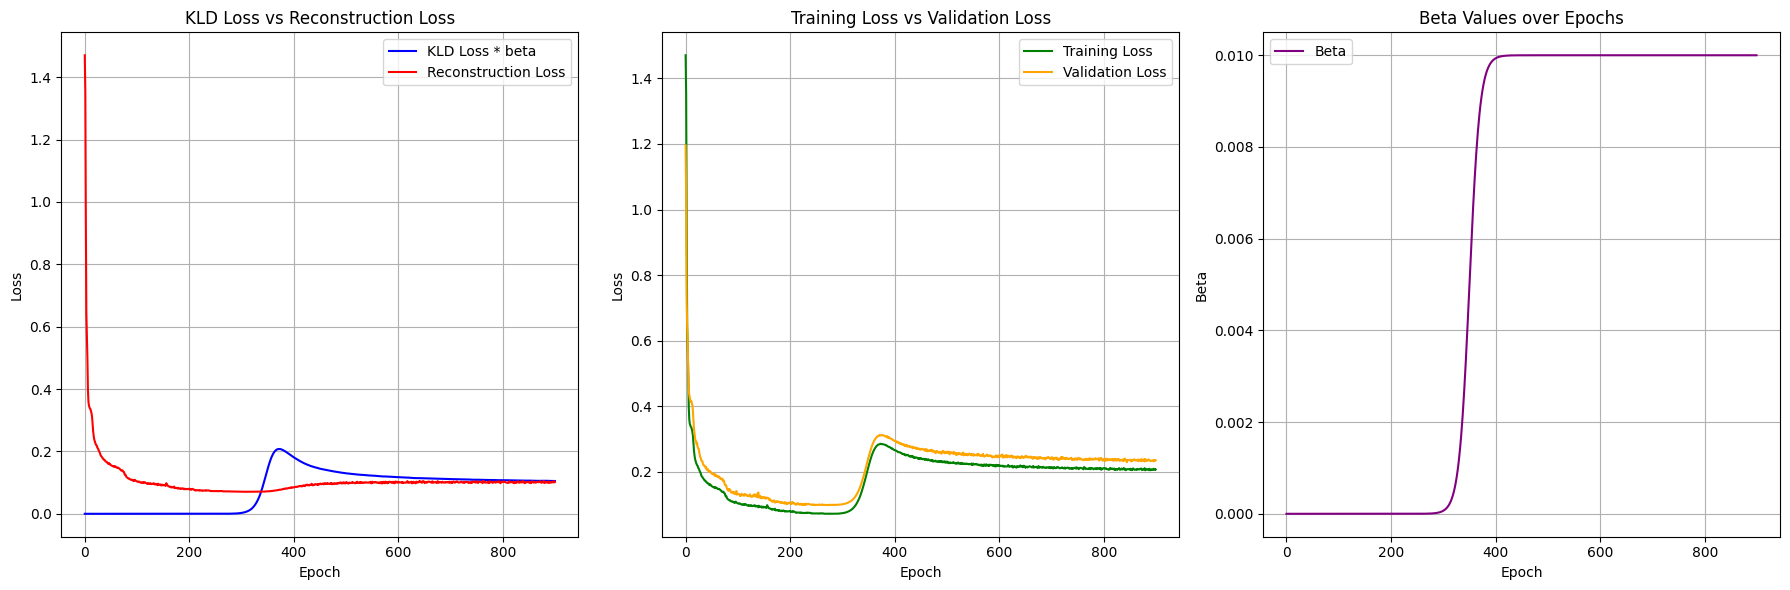

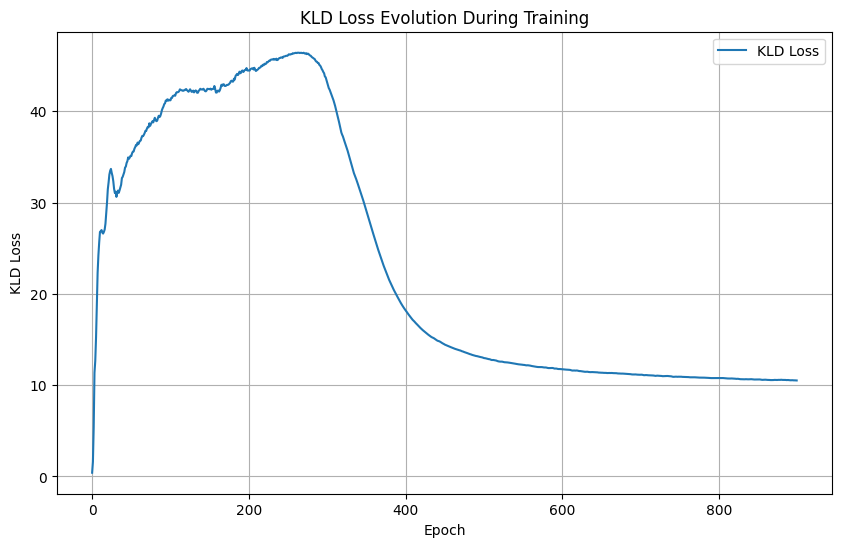

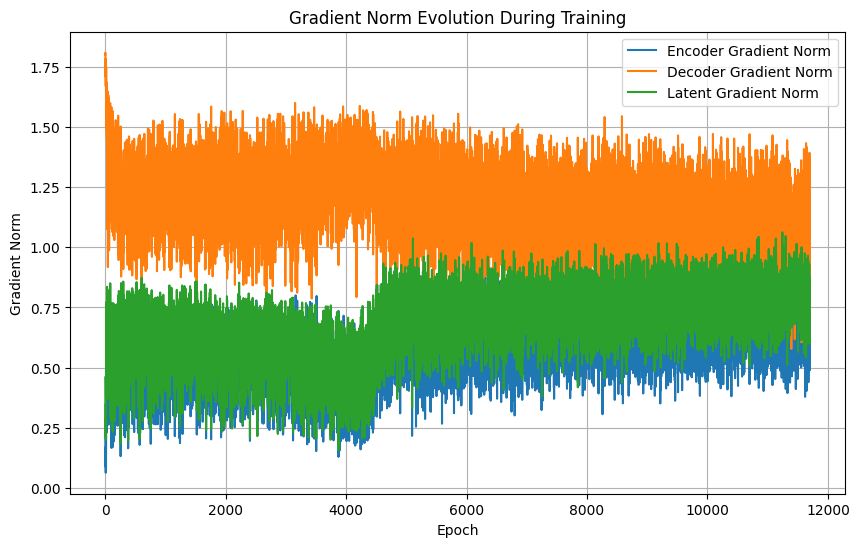

In [7]:
plot_results(encoder_train_losses, encoder_val_losses, recon_losses, kld_losses,effective_kld_losses, beta_values, encoder_gradient_history)

#### Decoder training:
Risultati del training del Decoder per la ricostruzione di $y_2(t)$ dal $y_1(t)$ :

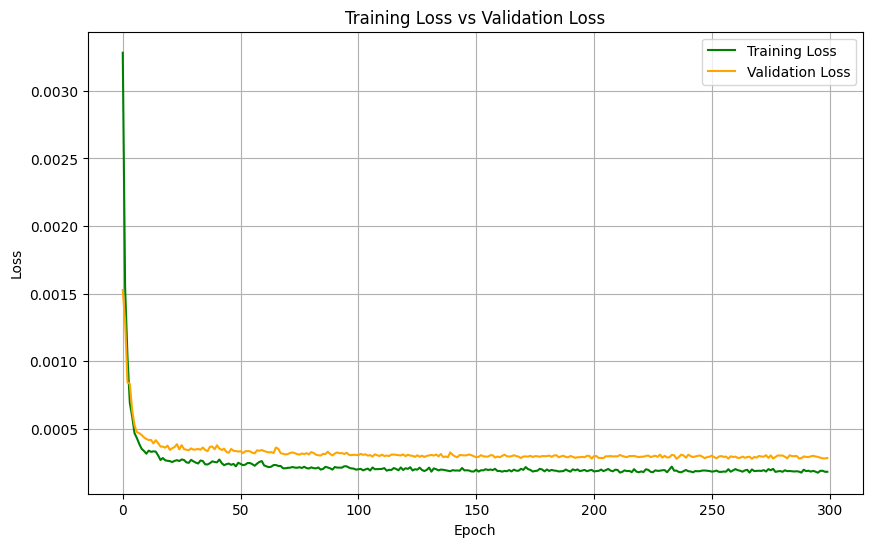

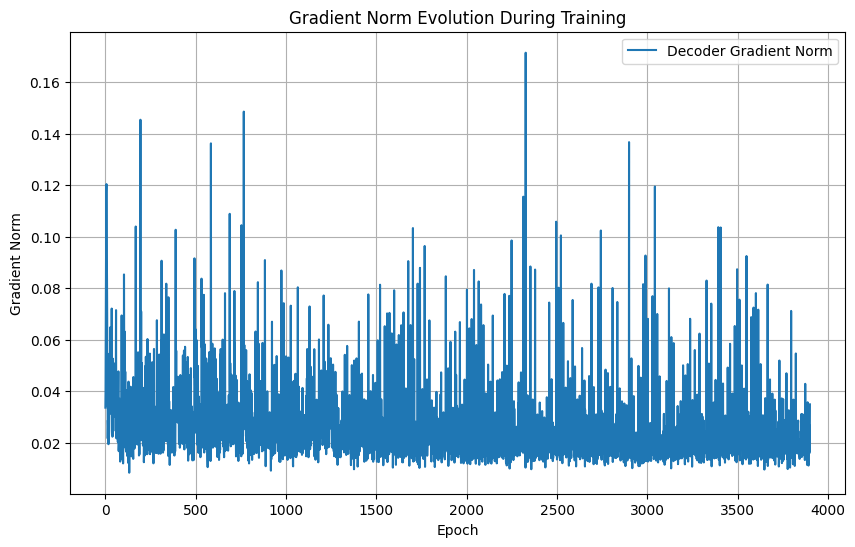

In [8]:
plot_Decoder_results(decoder_train_losses, decoder_val_losses, decoder_gradient_history)

### Validation Dataset:

The validation dataset is processed through the network as implemented in the 'Encoder.py' class and specified in the 'trainDecoder.ipynb' notebook. In this section, we will:

1. Post-process all data to reconstruct dynamics in the original dimensionality.
2. Analyze raw (non post-processed) data reconstruction and post-processed dynamic reconstruction.


In [9]:
#Creazione dell'istanza VAE con decoder ed encoder concatenati
vae_model = VAE(encoder, decoder)

input_data, predicted_data, mean_vectors, logvar_vectors = run_model_and_collect_outputs(vae_model, val_loader, device="cpu")

print("True data shape:", input_data.shape)
print("Predicted data shape:", predicted_data.shape)
print("Mean vectors shape:", mean_vectors.shape)
print("Logvar vectors shape:", logvar_vectors.shape)

#Taking the Z1,Z3 embedding from the VAE output
reconstructed_y2_1 = predicted_data[:, :20]  # Embedding di z1
reconstructed_y2_2 = predicted_data[:, 20:]  # Embedding di z3

#Taking Z1,Z3 embedding from Validation data
inputs, targets = zip(*[val_data[i] for i in range(len(val_data))])

# Converti in un tensore o array numpy per il plotting
inputs = torch.stack(inputs).numpy()
targets = torch.stack(targets).numpy()

original_y2_1 = targets[:, :20]
original_y2_2 = targets[:, 20:]

print("Reconstructed y2_1 shape:", reconstructed_y2_1.shape)
print("Reconstructed y2_2 shape:", reconstructed_y2_2.shape)
print("Targets shape:", targets.shape)
print("Original y2_1 shape:", original_y2_1.shape)
print("Original y2_2 shape:", original_y2_2.shape)

True data shape: (260, 15)
Predicted data shape: (260, 30)
Mean vectors shape: (260, 5)
Logvar vectors shape: (260, 5)
Reconstructed y2_1 shape: (260, 20)
Reconstructed y2_2 shape: (260, 10)
Targets shape: (260, 30)
Original y2_1 shape: (260, 20)
Original y2_2 shape: (260, 10)


Varianza spiegata: [0.44514167 0.26728752]


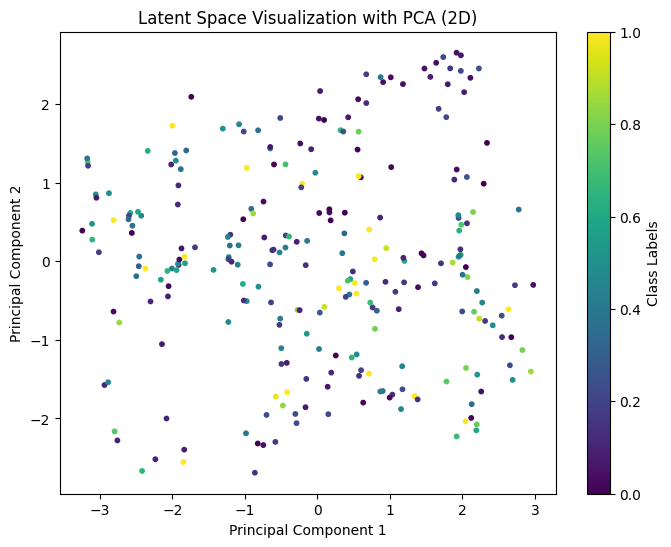

In [10]:
# Esegui la visualizzazione
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
visualize_latent_space_with_pca(vae_model, val_data, device=device, n_components=2)

### Z1,Z3 reconstruction analysis
Qua calcoliamo alcune metriche di ricostruzione direttamente tra gli output della rete e i target nel Dataloader.
Questo indice non quantifica benissimo quanto è ricostruito bene il segnale dato che nei vettori di embedding alcuni punti compaiono un numero ripetuto di volte, quindi la ricostruzione errata di un punto impatta in maniera significativa sulle metriche.

r2_score entries: 260
r2_score entries: 260
Indices of the 3 samples with the worst R² (z1): [150 136 139]
Mean R² for Z1 recon: -0.950523 pm 0.8434984
Indices of the 3 samples with the worst R² (z2): [116 121  69]
Mean R² for Z3 recon: -0.75451803 pm 1.1808044


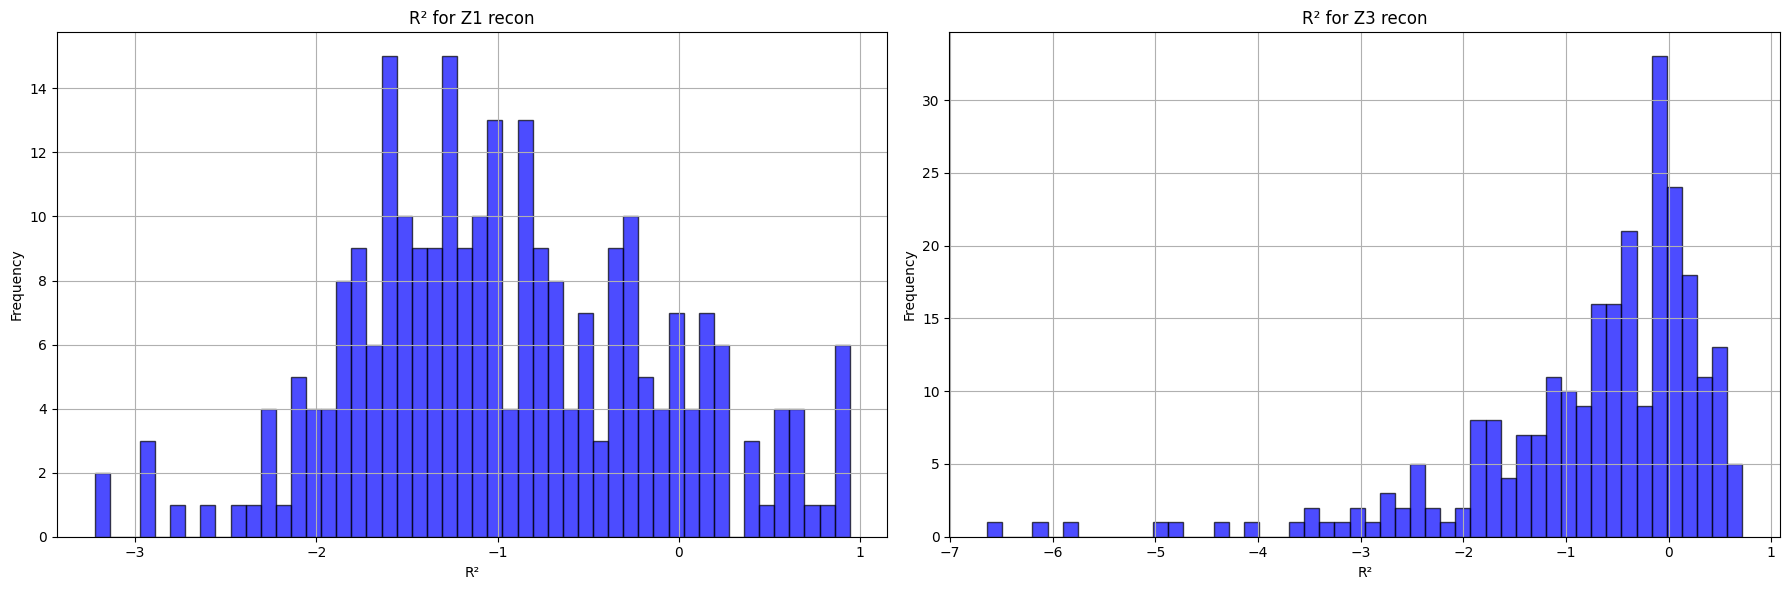

In [11]:
# Plot the R² histogram and get the indices of the worst R² samples
worst_r2_indices1, r2_scores1 = plot_r2_histogram(original_y2_1,reconstructed_y2_1)
mean_r21 = np.mean(r2_scores1)
std_r21 = np.std(r2_scores1)

worst_r2_indices2, r2_scores2 = plot_r2_histogram(original_y2_2,reconstructed_y2_2)
mean_r22 = np.mean(r2_scores2)
std_r22 = np.std(r2_scores2)


fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot R² histogram for Z1 recon
axes[0].hist(r2_scores1, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('R² for Z1 recon')
axes[0].set_xlabel('R²')
axes[0].set_ylabel('Frequency')
axes[0].grid(True)

print("Indices of the 3 samples with the worst R² (z1):", worst_r2_indices1)
print("Mean R² for Z1 recon:", mean_r21 , "pm", std_r21)

# Plot R² histogram for Z3 recon
axes[1].hist(r2_scores2, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[1].set_title('R² for Z3 recon')
axes[1].set_xlabel('R²')
axes[1].set_ylabel('Frequency')
axes[1].grid(True)

print("Indices of the 3 samples with the worst R² (z2):", worst_r2_indices2)
print("Mean R² for Z3 recon:", mean_r22 , "pm", std_r22)

plt.tight_layout()
plt.show()

Entries: 260


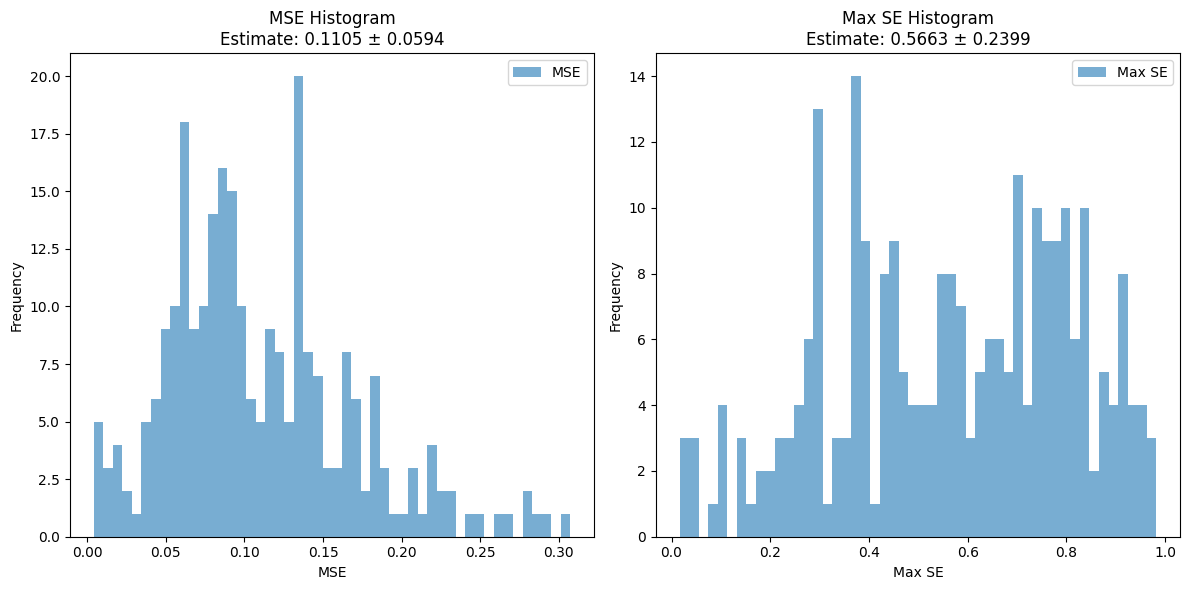

Indices of the 3 samples with the worst MAXse: [ 16 150 136]
Mean MSE for Z1 recon: 0.1104575 pm 0.059350453
Mean MAXse for Z1 recon: 0.56630343 pm 0.23989303
Entries: 260


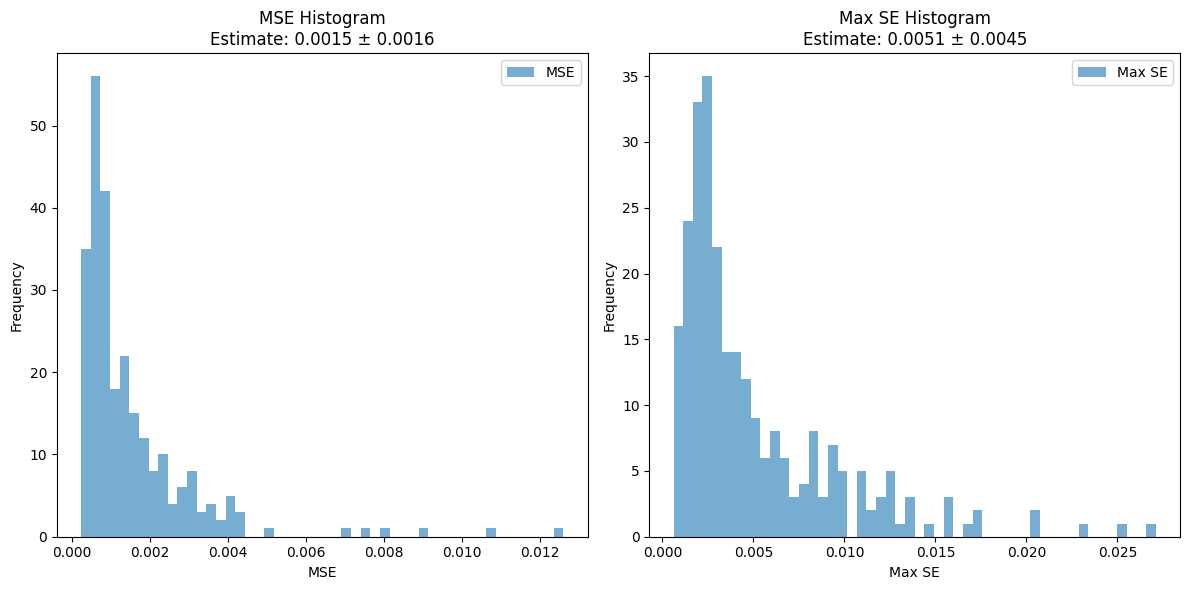

Indices of the 3 samples with the worst MAXse: [  5 140  23]
Mean MSE for Z3 recon: 0.0015143902 pm 0.0015724394
Mean MAXse for Z3 recon: 0.005059505 pm 0.004494816


In [12]:
# Calculate errors and plot histogram for Z1 recon
worst_max_se_indices1, best_mse_indices1, mse_errors1, max_se_errors1 = calculate_errors_and_plot_hist(original_y2_1, reconstructed_y2_1)
mean_mse = mse_errors1.mean()
std_mse = mse_errors1.std()
mean_max_se = max_se_errors1.mean()
std_max_se = max_se_errors1.std()
print("Indices of the 3 samples with the worst MAXse:", worst_max_se_indices1)

print("Mean MSE for Z1 recon:", mean_mse , "pm", std_mse)
print("Mean MAXse for Z1 recon:", mean_max_se , "pm", std_max_se)

# Calculate errors and plot histogram for Z3 recon
worst_max_se_indices2, best_mse_indices2, mse_errors2, max_se_errors2 = calculate_errors_and_plot_hist(original_y2_2, reconstructed_y2_2)
mean_mse2 = mse_errors2.mean()
std_mse2 = mse_errors2.std()
mean_max_se2 = max_se_errors2.mean()
std_max_se2 = max_se_errors2.std()
print("Indices of the 3 samples with the worst MAXse:", worst_max_se_indices2)

print("Mean MSE for Z3 recon:", mean_mse2 , "pm", std_mse2)
print("Mean MAXse for Z3 recon:", mean_max_se2 , "pm", std_max_se2)

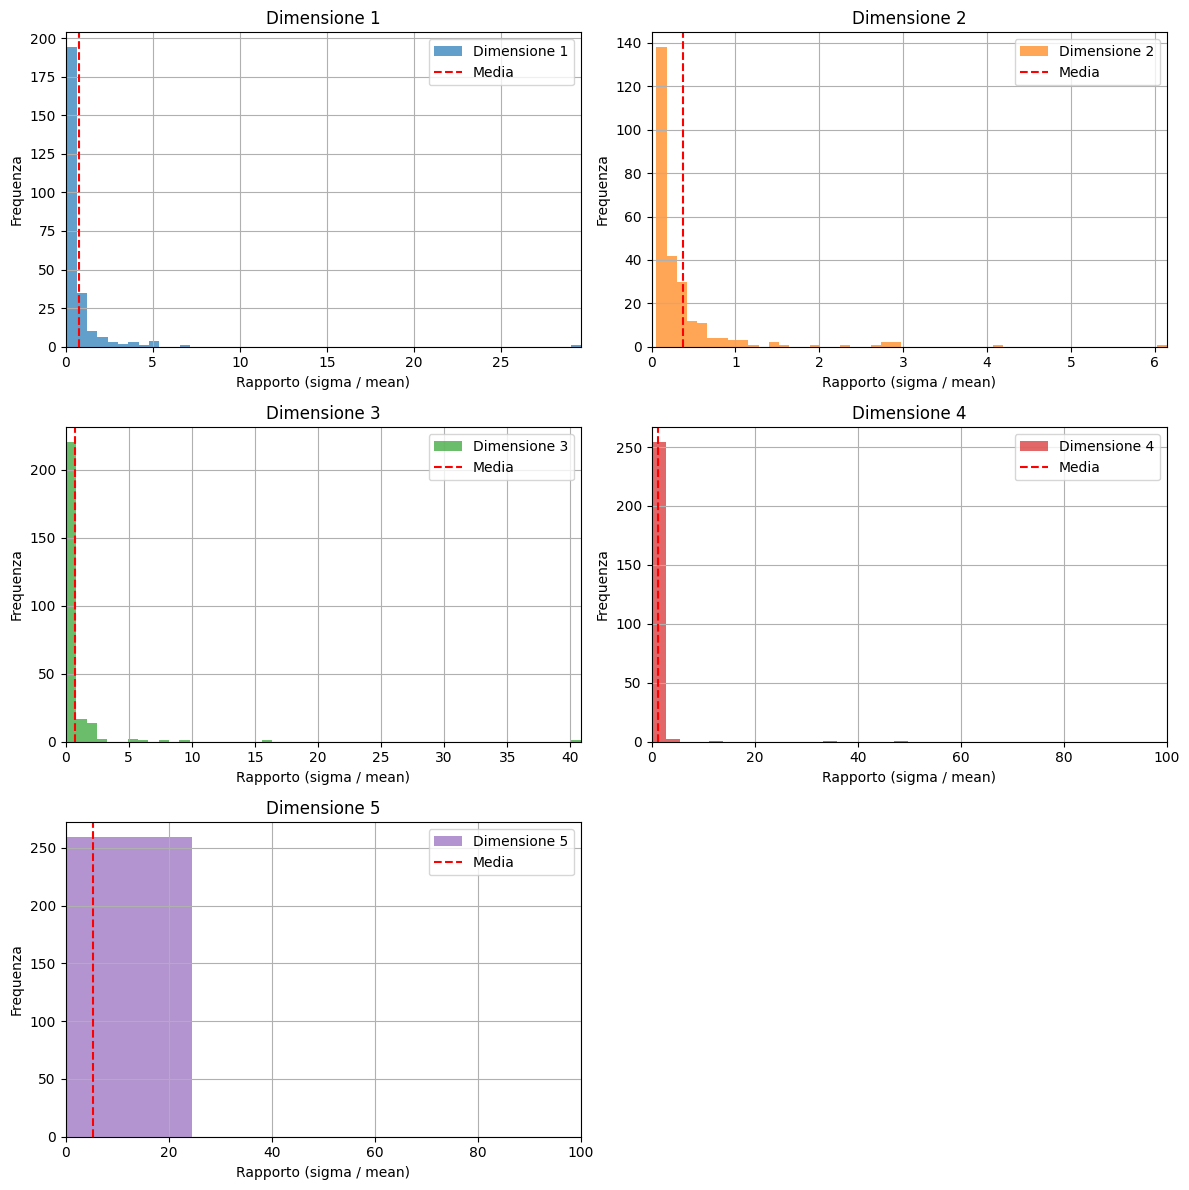

In [13]:
latent_variables(vae_model,mean_vectors,logvar_vectors,val_loader,'cpu')

### Grafico del segnale di: $y_2 =[z1,z3]^T + \beta \cdot \sigma$:

Confrontiamo il segnale temporale di $Z_1$ e $Z_3$ dal dataset di Validazione con le ricostruzioni degli output della rete.
Calcoliamo alcune metriche per valutare la ricostruzione. Vengono mediamente più elevate poichè dopo aver ricostruito il segnale dagli embedding i punti anomali ripetendosi una sola volta (contro le n volte nei vettori di embedding) danno un contributo minore.


In [14]:
# Ricostruzione di Z1 dal suo embedding (Validation data)
val_Z1 = reconstruct_signal_from_embedding(
    original_y2_1, embedding_dim, tau
)
#Ricostruzione da Z3 dal suo embedding (Validation data)
val_Z3 = reconstruct_signal_from_embedding(
    original_y2_2, embedding_dim, tau
)


# Ricostruzione di Z1 dal suo embedding (Ricostruito)
recon_Z1 = reconstruct_signal_from_embedding(
    reconstructed_y2_1, embedding_dim, tau
)
#Ricostruzione da Z3 dal suo embedding (Ricostruito)
recon_Z3 = reconstruct_signal_from_embedding(
    reconstructed_y2_2, embedding_dim, tau
)

val_Z2 = reconstruct_signal_from_embedding(
    inputs, embedding_dim, tau
)

# Calcola l'errore quadratico medio
mse1 = np.mean((val_Z1 - recon_Z1) ** 2)
mse2 = np.mean((val_Z3 - recon_Z3) ** 2)

# Calcolo R2:

r2_1 = r2_score(val_Z1, recon_Z1)
r2_2 = r2_score(val_Z3, recon_Z3)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Segnale y2(1)
axes[0].plot(val_Z1, label="z1", color='blue', lw=0.5)
axes[0].plot(recon_Z1, label="z1 recon", color='orange', lw=0.5)
axes[0].legend()
axes[0].set_title(r"$Z_1$ recon: MSE = {:.4f}, R² = {:.4f}".format(mse1, r2_1))
axes[0].set_xlabel("Tempo")
axes[0].set_ylabel("$z_1$")

# Segnale y2(2)
axes[1].plot(val_Z3, label="z3", color='orange', lw=0.5)
axes[1].plot(recon_Z3, label="z3 recon", color='blue', alpha=0.5, lw=0.5)
axes[1].legend()
axes[1].set_title(r"$Z_3$ recon: MSE = {:.4f}, R² = {:.4f}".format(mse2, r2_2))
axes[1].set_xlabel("Tempo")
axes[1].set_ylabel("$z_3$")

plt.tight_layout()
plt.show()

IndexError: index 10 is out of bounds for axis 1 with size 10

### Analisi delle Componenti principali:

In questa cella vengono presi i dati di input e gli output della rete (ovvero gli input ricostruiti).
Si fa una PCA sui dati di input e una volta trovate le direzioni di massima varianza sui dati originali proiettiamo sia i dati ricostruiti dalla rete che i dati originali lungo le direzioni di massima varianza. Una volta fatto questo calcoliamo il coefficiente $R^2$ tra le due proiezioni. /
Bisogna fare attenzione allo shape, embedding_dim diventa il numero di features per la PCA

In [ ]:
# Confronta PC per Z1
r2_z1, ind2 = pca_r2_analysis_embeddings(original_y2_1, reconstructed_y2_1, n_components=6)

# Confronta PC per Z2
r2_z2, ind3 = pca_r2_analysis_embeddings(original_y2_2, reconstructed_y2_2, n_components=6)

### Ricostruzione delle PC:

#### 1- Ricostruzione delle PC di $y_1(t) = Z_2(t) + \beta \cdot \sigma$ dagli embedding di $Z_1,Z_3$

In questo grafico analizziamo la capacità della rete di ricostruire le PC del segnale di input.
Dall'embedding del segnale di input: $y_1(t) = Z_2(t) + \beta \cdot \sigma$ calcoliamo le direzioni di massima varianza dei dati originali e in seguito proiettiamo gli output della rete, gli embedding di $y_2(t) = [Z_1 (t),Z_3 (t)]^T + \beta \cdot \sigma$, lungo le direzioni calcolate in precedenza e calcoliamo l'indice $R^2$ tra la PC# originale e quella ricostruita.

In [16]:
def plot_temporal_signal_and_pcs(original_signal, original_embeddings, reconstructed_embeddings, n_components=3):
    """
    Plotta il segnale temporale originale, le PC calcolate dagli embedding originali,
    e le PC ricostruite dagli embedding di output della rete per ogni componente principale.
    
    Parameters:
        original_signal (np.ndarray): Segnale temporale originale (1D array).
        original_embeddings (np.ndarray): Embedding del segnale originale (2D array).
        reconstructed_embeddings (np.ndarray): Embedding ricostruito dalla rete (2D array).
        n_components (int): Numero di componenti principali da calcolare.
    """
    # PCA sugli embedding originali
    pca = PCA(n_components=n_components)
    pc_original = pca.fit_transform(original_embeddings)  # Tutte le PC dagli embedding originali
    pc_reconstructed = pca.transform(reconstructed_embeddings)  # Proiezione delle PC ricostruite

    # Plot per ogni componente principale
    for i in range(n_components):
        # Calcola R^2 tra la PC originale e quella ricostruita
        r2 = r2_score(pc_original[:, i], pc_reconstructed[:, i])

        # Plot
        plt.figure(figsize=(12, 6))
        plt.plot(original_signal, label='Input signal', color='black', lw=1.5)
        plt.plot(pc_original[:, i], label=f'PC{i+1} ', color='orange', lw=1.5)
        plt.plot(pc_reconstructed[:, i], label=f'PC{i+1} recon', linestyle='--', color='blue', alpha=0.7, lw=1.5)
        plt.title(f"Confronto tra Segnale Temporale e PC{i+1} Ricostruite - $R^2$: {r2:.2f}")
        plt.xlabel("Time (t)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.show()


In [ ]:
plot_temporal_signal_and_pcs(val_Z2, inputs, reconstructed_y2_1, n_components=3)

#### 2- Ricostruzione delle PC di $y_2(t)$ dagli embedding di $Z_1,Z_3$

In questo grafico analizziamo la capacità della rete di ricostruire le PC dei veri dati che la rete dovrebbe restituire.
Per le componenti di $y_2(t) = [Z_1,Z_3]^T + \beta \cdot \sigma$ costruiamo dai dati originali le matrici contenenti gli embedding. Poi uniamo le due matrici contenenti gli embedding delle variabili $[Z_1,Z_3]$ ottenendo una Matrice con shape (n_samples, 2* embedding dim ) in cui sono concatenati gli embedding delle due variabili e in seguito. Si usa poi su questi PCA.fit per calcolare media e varianza delle componenti principali e transform per ridurre la dimensionalità dei dati originali e plottare la componente principale come un segnale temporale.
Si applica poi la trasformazione sugli output della rete combinati allo stesso modo proiettandoli sulle componenti principali dei dati di reali.
Si calcola poi l'indice $R^2$ per analizzare la varianza tra la PC# ottenuta dai dati originali e la proiezione dei dati di output sulle stesse componenti.


In [ ]:
def plot_pca_comparison_combined(original_signal, original_embeddings_z1, original_embeddings_z3, reconstructed_embeddings_z1, reconstructed_embeddings_z3, n_components=3):
    """
    Confronta il segnale temporale originale, le PC calcolate dagli embedding originali combinati,
    e le PC ricostruite combinando gli embedding di output della rete per \( Z1 \) e \( Z3 \).
    
    Parameters:
        original_signal (np.ndarray): Segnale temporale originale (1D array).
        original_embeddings_z1 (np.ndarray): Embedding originale di \( Z1 \) (2D array).
        original_embeddings_z3 (np.ndarray): Embedding originale di \( Z3 \) (2D array).
        reconstructed_embeddings_z1 (np.ndarray): Embedding ricostruito dalla rete per \( Z1 \) (2D array).
        reconstructed_embeddings_z3 (np.ndarray): Embedding ricostruito dalla rete per \( Z3 \) (2D array).
        n_components (int): Numero di componenti principali da calcolare.
    """
    # Combina gli embedding originali di Z1 e Z3
    original_embeddings_combined = np.hstack([original_embeddings_z1, original_embeddings_z3])
    # Combina gli embedding ricostruiti di Z1 e Z3
    reconstructed_embeddings_combined = np.hstack([reconstructed_embeddings_z1, reconstructed_embeddings_z3])

    # PCA sugli embedding combinati originali
    pca = PCA(n_components=n_components)
    pc_original = pca.fit_transform(original_embeddings_combined)  # Tutte le PC dagli embedding originali combinati
    pc_reconstructed = pca.transform(reconstructed_embeddings_combined)  # Proiezione delle PC combinate ricostruite

    # Plot per ogni componente principale
    for i in range(n_components):
        # Calcola R^2 tra la PC originale e quella ricostruita
        r2 = r2_score(pc_original[:, i], pc_reconstructed[:, i])

        # Plot
        plt.figure(figsize=(12, 6))
        plt.plot(original_signal, label='Input signal', color='black', lw=1.5)
        plt.plot(pc_original[:, i], label=f'PC{i+1}', color='orange', lw=1.5)
        plt.plot(pc_reconstructed[:, i], label=f'PC{i+1} recon', linestyle='--', color='blue', alpha=0.7, lw=1.5)
        plt.title(f"Confronto tra Segnale Temporale e PC{i+1} Ricostruite (Z1+Z3) - $R^2$: {r2:.2f}")
        plt.xlabel("Time (t)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.show()


In [ ]:
plot_pca_comparison_combined(val_Z2, original_y2_1, original_y2_2, reconstructed_y2_1, reconstructed_y2_2, n_components=3)

In [ ]:
# Combina gli embedding originali di Z1 e Z3
original_embeddings_combined = np.hstack([original_y2_1, original_y2_2])
# Combina gli embedding ricostruiti di Z1 e Z3
reconstructed_embeddings_combined = np.hstack([reconstructed_y2_1, reconstructed_y2_2])

r2_Z1Z3, ind4 = pca_r2_analysis_embeddings(original_embeddings_combined, reconstructed_embeddings_combined, n_components=6)

In [ ]:
output_path = "Decoder Analysis Data"
output_path += f"/{decoder_name}"
output_path += ".csv"

print (output_path)

save_decoder_analysis_data(model_name=decoder_name, 
                   latent_dim = decoder_config["latent_dim"], 
                   r2_mean1 = mean_r21, r2_std1 = std_r21, 
                   mse_mean1 = mean_mse, mse_std1 = std_mse, 
                   maxse_mean1 = mean_max_se, maxse_std1 = std_max_se,
                   r2_mean2 = mean_r22, r2_std2 = std_r22,
                   mse_mean2 = mean_mse2, mse_std2 = std_mse2,
                   maxse_mean2 = mean_max_se2, maxse_std2 = std_max_se2,
                   r2_z1 = r2_z1, r2_z2 = r2_z2,r2_Z1Z3 = r2_Z1Z3,
                   r2_t_Z1=r2_1, r2_t_Z3=r2_2,
                   ind1= ind2, ind2=ind3, ind3=ind4,
                   file_path=output_path)